In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp
from scipy.stats import kruskal, ttest_ind

In [2]:
def cohens_d(group1, group2):
    # Means and standard deviations of both groups
    mean1, mean2 = np.mean(group1), np.mean(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    n1, n2 = len(group1), len(group2)
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    
    # Cohen's d formula
    d = (mean1 - mean2) / pooled_std
    return d

def classify_effect_size(d):
    # Classify based on Cohen's d thresholds
    abs_d = abs(d)  # Use absolute value of Cohen's d
    abs_d = round(abs_d, 2)  # Round Cohen's d to two decimal places
    if abs_d < 0.2:
        return 'Small', abs_d
    elif abs_d <= 0.8:
        return 'Medium', abs_d
    else:
        return 'Large', abs_d


In [3]:
#Read in paired glob, RR, obs dual filtered data and subset relevant columns
glob_RR_obs = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs/Clean and filtered RR Glob Obs timeseries.csv')
glob_RR_obs = glob_RR_obs[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'longitude', 'Modelled_RR', 'Modelled_global', 'Observed','Variable']]

#Convert to long format
glob_RR_obs_long = pd.melt(glob_RR_obs, id_vars = ['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'longitude', 'Variable'], var_name = 'Source')
glob_RR_obs_long

,siteId,SamplingInt,dateOnround,dateOffround,latitude,longitude,Variable,Source,value
0,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,WetDep_SO4_mgm2,Modelled_RR,16.465559
1,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,WetDep_NO3_mgm2,Modelled_RR,30.453215
2,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,WetDep_NH4_mgm2,Modelled_RR,3.010674
3,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,Precipitation_mm,Modelled_RR,40.754309
4,AL10,572.0,2017-02-01,2017-02-08,32.4583,-87.2422,WetDep_SO4_mgm2,Modelled_RR,7.431907
...,...,...,...,...,...,...,...,...,...
86521,WY08,2.0,2017-05-16,2017-05-23,44.9166,-110.4203,Precipitation_mm,Observed,25.400000
86522,WY08,3.0,2017-09-13,2017-09-20,44.9166,-110.4203,WetDep_DOC_mgm2,Observed,34.861500
86523,WY08,3.0,2017-09-13,2017-09-20,44.9166,-110.4203,Precipitation_mm,Observed,57.150000
86524,WY08,4.0,2017-11-14,2017-11-22,44.9166,-110.4203,WetDep_DOC_mgm2,Observed,6.720840


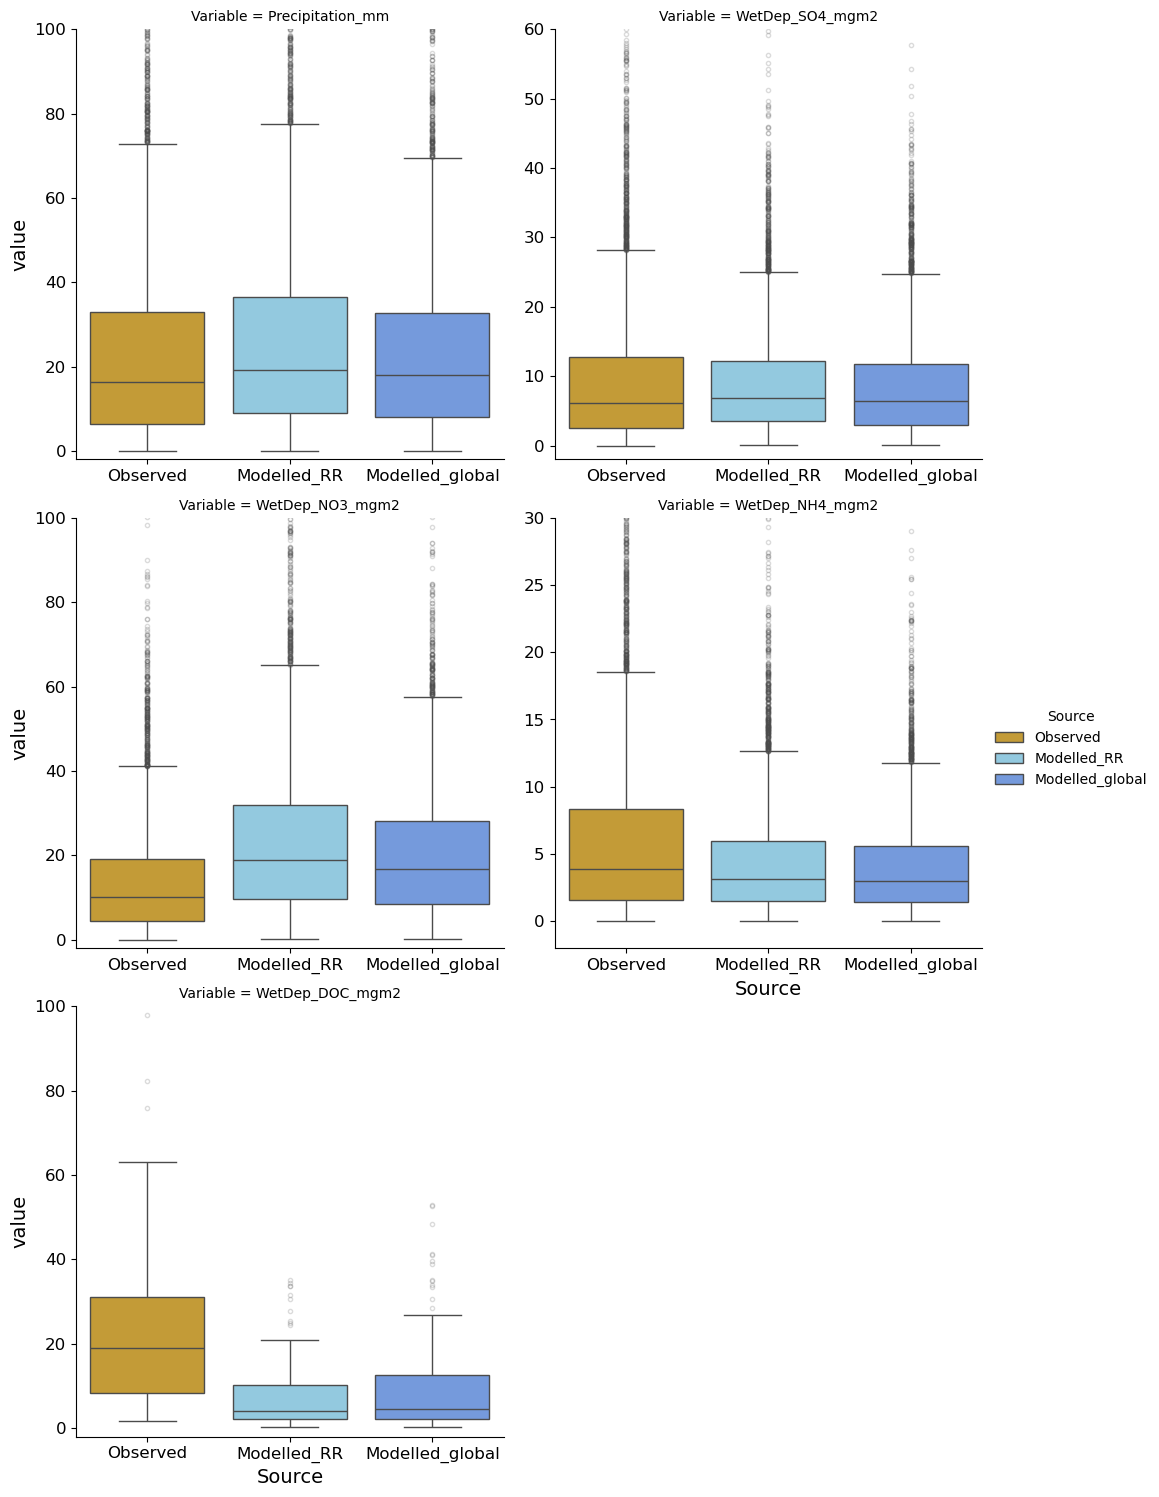

In [4]:
# Ensure 'Source' is a categorical variable with a consistent order
source_order = ['Observed', 'Modelled_RR', 'Modelled_global']
glob_RR_obs_long['Source'] = pd.Categorical(glob_RR_obs_long['Source'], categories=source_order, ordered=True)

# Define the desired order for 'Variable'
desired_order = ['Precipitation_mm', 'WetDep_SO4_mgm2', 'WetDep_NO3_mgm2', 'WetDep_NH4_mgm2', 'WetDep_DOC_mgm2']
glob_RR_obs_long['Variable'] = pd.Categorical(glob_RR_obs_long['Variable'], categories=desired_order, ordered=True)

# Sort the dataframe by the new order if needed
glob_RR_obs_long = glob_RR_obs_long.sort_values(by=['Variable', 'Source'])

custom_palette = {'Modelled_RR': 'skyblue', 'Modelled_global': 'cornflowerblue', 'Observed': 'goldenrod'}

flierprops = {
    'marker': 'o',        # Marker style
    'markersize': 3,      # Size of the marker
    'linestyle': 'none',   # No connecting line
    'alpha': 0.2
}

# Create the plot
g = sns.catplot(
    data=glob_RR_obs_long,
    x='Source', y='value',
    col='Variable', kind='box', col_wrap=2, sharex=False, sharey=False, hue='Source',
    palette=custom_palette, flierprops=flierprops, legend=True,
    order=source_order  # Ensure consistent x-axis order
)

# Custom y-axis limits for each facet
y_limits = {
    'Precipitation_mm': (-2, 100),
    'WetDep_SO4_mgm2': (-2, 60),
    'WetDep_NO3_mgm2': (-2, 100),
    'WetDep_NH4_mgm2': (-2, 30),
    'WetDep_DOC_mgm2': (-2, 100),
}

# Iterate over facets to set y-axis limits and adjust text size
for ax, variable in zip(g.axes.flatten(), y_limits):
    ax.set_ylim(y_limits[variable])
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)  # Increase x-axis label font size
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)  # Increase y-axis label font size
    ax.tick_params(axis='both', labelsize=12)  # Increase tick label size

# Save figure
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/Filtered_RR_Global_Obs_boxplot.jpg', format='jpg', dpi=300)  # Adjust quality as needed
plt.show()


In [5]:
glob_RR_obs_long.groupby('Variable')['value'].max()

Variable
Precipitation_mm    430.276000
WetDep_SO4_mgm2     392.277600
WetDep_NO3_mgm2     154.097042
WetDep_NH4_mgm2      89.374472
WetDep_DOC_mgm2     150.146900
Name: value, dtype: float64

In [6]:
# Get unique variables
unique_variables = glob_RR_obs_long['Variable'].unique()

# For each variable
for variable in unique_variables:
    # Subset the data for the current variable
    subset_data = glob_RR_obs_long[glob_RR_obs_long['Variable'] == variable]
    
    # Prepare groups for the Kruskal-Wallis test
    groups = [subset_data['value'][subset_data['Source'] == g] for g in subset_data['Source'].unique()]
    
    # Perform Kruskal-Wallis Test
    h_stat, p_value = kruskal(*groups)
    print(f"\n--- Kruskal-Wallis Test for Variable: {variable} ---")
    print(f"H-statistic: {h_stat:.4f}, p-value: {p_value:.4e}")
    
    # If the Kruskal-Wallis test is significant (p < 0.01), perform post-hoc Dunn's test
    if p_value < 0.01:
        print("\nPost-hoc Dunn's Test (Significant comparisons):")
        
        # Perform Dunn's test using scikit-posthocs
        dunn_result = sp.posthoc_dunn(subset_data, val_col='value', group_col='Source', p_adjust='bonferroni')
        
        # Print the full Dunn's test results matrix
        print(dunn_result)
        
        # Highlight the significant comparisons (p-value < 0.01)
        print("\nSignificantly different group pairs with Cohen's d:")
        for i in range(len(dunn_result.columns)):
            for j in range(i):
                p_val = dunn_result.iloc[i, j]
                if p_val < 0.01:
                    group1 = dunn_result.columns[i]
                    group2 = dunn_result.columns[j]
                    
                    # Extract the groups' data
                    group1_data = subset_data['value'][subset_data['Source'] == group1]
                    group2_data = subset_data['value'][subset_data['Source'] == group2]
                    
                    # Calculate Cohen's d for the pair
                    d = cohens_d(group1_data, group2_data)
                    
                    # Classify the effect size
                    effect_size_class, abs_d = classify_effect_size(d)
                    print(f"  {group1} vs {group2}: p-value = {p_val:.4e}, Cohen's d = {abs_d:.4f} ({effect_size_class})")
    else:
        print("No significant difference found. Post-hoc test skipped.")



--- Kruskal-Wallis Test for Variable: Precipitation_mm ---
H-statistic: 116.3993, p-value: 5.2993e-26

Post-hoc Dunn's Test (Significant comparisons):
                     Observed   Modelled_RR  Modelled_global
Observed         1.000000e+00  1.333296e-26     2.325896e-06
Modelled_RR      1.333296e-26  1.000000e+00     1.613479e-08
Modelled_global  2.325896e-06  1.613479e-08     1.000000e+00

Significantly different group pairs with Cohen's d:
  Modelled_RR vs Observed: p-value = 1.3333e-26, Cohen's d = 0.1200 (Small)
  Modelled_global vs Observed: p-value = 2.3259e-06, Cohen's d = 0.0200 (Small)
  Modelled_global vs Modelled_RR: p-value = 1.6135e-08, Cohen's d = 0.1500 (Small)

--- Kruskal-Wallis Test for Variable: WetDep_SO4_mgm2 ---
H-statistic: 46.8353, p-value: 6.7585e-11

Post-hoc Dunn's Test (Significant comparisons):
                     Observed   Modelled_RR  Modelled_global
Observed         1.000000e+00  1.039000e-09     1.000000e+00
Modelled_RR      1.039000e-09  1.000000e